# 01 · Ornstein-Uhlenbeck Calibration

<a href="https://colab.research.google.com/github/drsamirasaf-creator/ge-lav-companion-code/blob/main/notebooks/01_ou_calibration.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

**Sessions covered:** S04 (OU intuition), S19 (Brownian motion & Itô), S22 (Fokker-Planck).

**You will learn how to:**
- Simulate paths of the OU process `dL = κ(L̄ − L)·dt + σ·dW`.
- Calibrate `(κ, σ, L̄)` from an observed L_t time series via MLE on the exact transition density.
- Verify the stationary distribution against simulation.
- Estimate the half-life and confidence intervals on the calibrated parameters.

**Course calibration (used as the book's default throughout):**
- `κ = 0.45 / yr`  (half-life ≈ 1.54 yrs)
- `σ = 0.32`
- `L̄ = 1.0`
- stationary std ≈ 0.337


In [1]:
# Colab setup: install gelav from the public repo if not already present
import importlib
if importlib.util.find_spec("gelav") is None:
    import subprocess
    subprocess.run(["pip", "install", "-q",
                    "git+https://github.com/drsamirasaf-creator/ge-lav-companion-code.git"],
                   check=True)

# Standard imports used across all notebooks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 10,
})

# Course colors
NAVY = "#1E3A5F"
GOLD = "#C89B3C"
RED  = "#C0392B"
GRAY = "#6B7280"

## 1. Simulating an OU path

Let's first see what L_t looks like under the book's calibration.

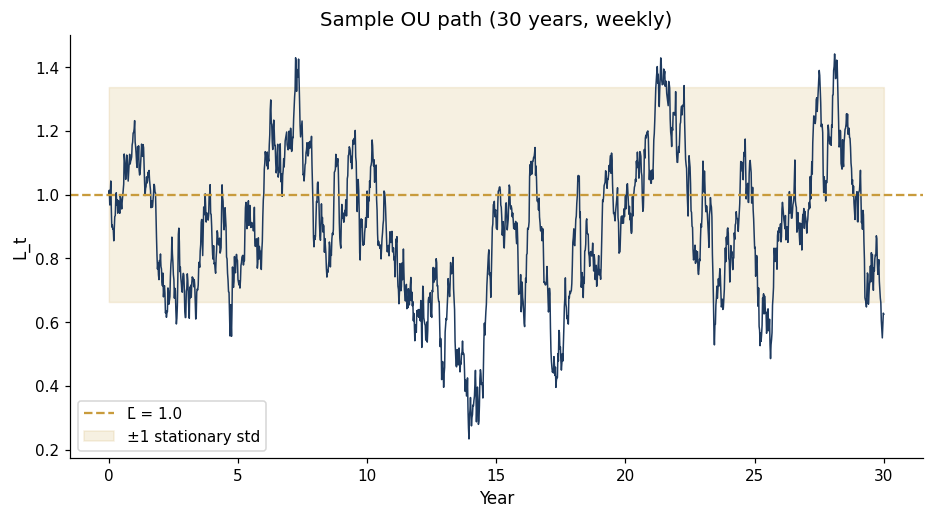

Half-life: 1.54 years
Stationary distribution: Normal(1.0, 0.1138) -> std = 0.3373


In [2]:
from gelav.ou import simulate_ou, stationary_distribution, half_life

# Book parameters
kappa, sigma, L_bar = 0.45, 0.32, 1.0
T = 30  # 30 years
dt = 1/52  # weekly steps

# Simulate one path
paths = simulate_ou(L0=L_bar, kappa=kappa, sigma=sigma, L_bar=L_bar,
                    T=T, dt=dt, n_paths=1, seed=42)

# Plot
fig, ax = plt.subplots()
times = np.linspace(0, T, paths.shape[1])
ax.plot(times, paths[0], color=NAVY, linewidth=1.0)
ax.axhline(L_bar, color=GOLD, linestyle="--", label=f"L̄ = {L_bar}")
ax.fill_between(times, L_bar - 0.337, L_bar + 0.337, alpha=0.15, color=GOLD,
                label="±1 stationary std")
ax.set(xlabel="Year", ylabel="L_t", title="Sample OU path (30 years, weekly)")
ax.legend()
plt.show()

print(f"Half-life: {half_life(kappa):.2f} years")
mean, std = stationary_distribution(kappa, sigma, L_bar)
print(f"Stationary distribution: Normal({mean}, {std**2:.4f}) -> std = {std:.4f}")

## 2. Stationary distribution check

Simulate many paths and compare the empirical density at large t to the theoretical stationary.

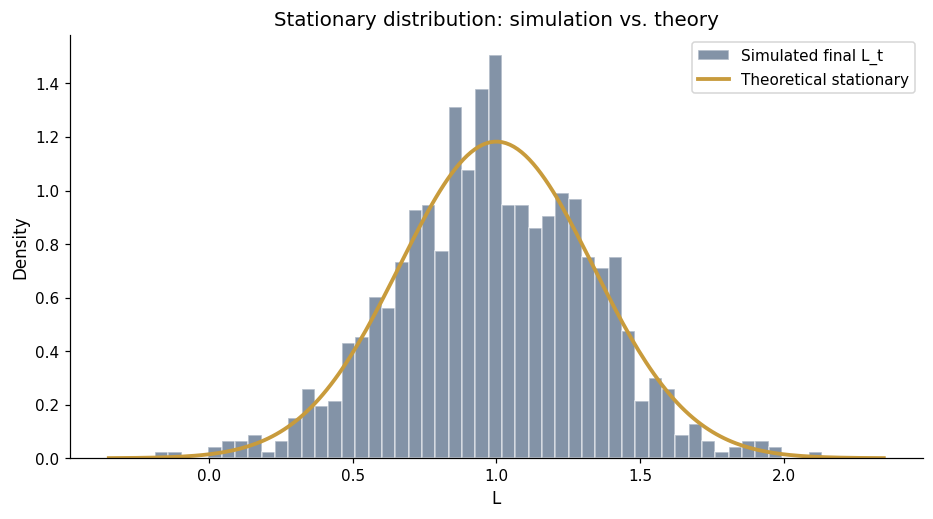

Empirical mean = 0.9908  (theory: 1.0)
Empirical std  = 0.3398  (theory: 0.3373)


In [3]:
# 1,000 paths, 50 years, take final values
paths_many = simulate_ou(L0=0, kappa=kappa, sigma=sigma, L_bar=L_bar,
                         T=50, dt=1/52, n_paths=1000, seed=123)
final_values = paths_many[:, -1]

fig, ax = plt.subplots()
ax.hist(final_values, bins=50, density=True, alpha=0.55, color=NAVY,
        edgecolor="white", label="Simulated final L_t")

# Overlay theoretical N(L̄, σ²/(2κ))
mean, std = stationary_distribution(kappa, sigma, L_bar)
L_range = np.linspace(mean - 4*std, mean + 4*std, 200)
density = np.exp(-(L_range - mean)**2 / (2*std**2)) / (std * np.sqrt(2*np.pi))
ax.plot(L_range, density, color=GOLD, linewidth=2.5, label="Theoretical stationary")
ax.set(xlabel="L", ylabel="Density",
       title="Stationary distribution: simulation vs. theory")
ax.legend()
plt.show()

print(f"Empirical mean = {final_values.mean():.4f}  (theory: {mean})")
print(f"Empirical std  = {final_values.std():.4f}  (theory: {std:.4f})")

## 3. Calibration from observed data

Now we'll calibrate `(κ, σ, L̄)` from a single L_t series, using MLE on the exact OU transition density.

We use the **synthetic L history** included in the repo (30 years of quarterly data). This mimics the structure of data you'd build from secondary-market discount observations and macro indicators.

        date       L_t
0 1996-01-01  1.000000
1 1996-04-01  1.048755
2 1996-07-01  0.876872
3 1996-10-01  1.010796
4 1997-01-01  1.160072

Observations: 121
Date range: 1996-01-01 00:00:00 to 2026-01-01 00:00:00
L_t range: [0.255, 1.521]


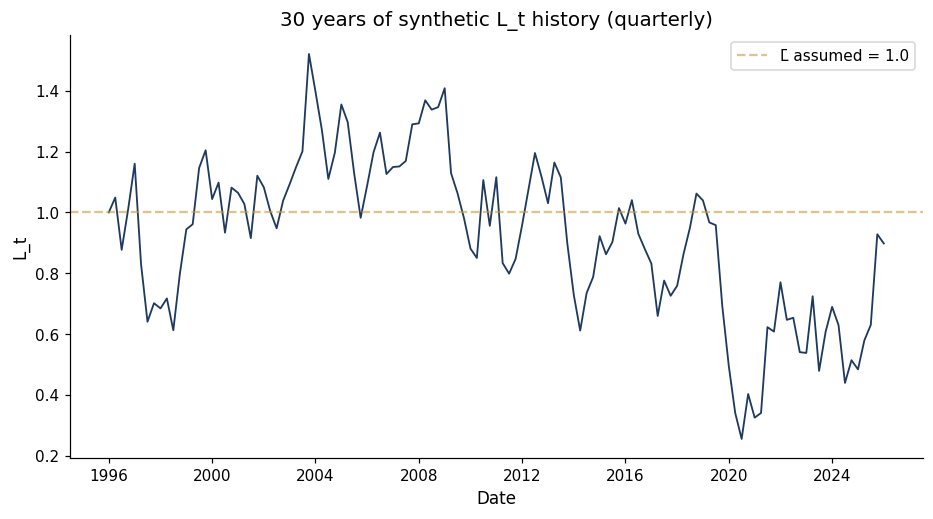

In [4]:
import pandas as pd
L_hist = pd.read_csv("../data/synthetic_L_history.csv", parse_dates=["date"])
print(L_hist.head())
print(f"\nObservations: {len(L_hist)}")
print(f"Date range: {L_hist['date'].min()} to {L_hist['date'].max()}")
print(f"L_t range: [{L_hist['L_t'].min():.3f}, {L_hist['L_t'].max():.3f}]")

# Plot the series
fig, ax = plt.subplots()
ax.plot(L_hist["date"], L_hist["L_t"], color=NAVY, linewidth=1.2)
ax.axhline(1.0, color=GOLD, linestyle="--", alpha=0.6, label="L̄ assumed = 1.0")
ax.set(xlabel="Date", ylabel="L_t", title="30 years of synthetic L_t history (quarterly)")
ax.legend()
plt.show()

In [5]:
from gelav.ou import calibrate_ou

# Quarterly data => dt = 0.25 yr
result = calibrate_ou(L_hist["L_t"].values, dt=0.25)

print("Calibrated parameters:")
print(f"  kappa  = {result['kappa']:.4f}  (true: 0.45)")
print(f"  sigma  = {result['sigma']:.4f}  (true: 0.32)")
print(f"  L_bar  = {result['L_bar']:.4f}  (true: 1.0)")
print(f"  log-likelihood = {result['log_likelihood']:.2f}")
print(f"  converged: {result['converged']}")

Calibrated parameters:
  kappa  = 0.5122  (true: 0.45)
  sigma  = 0.2663  (true: 0.32)
  L_bar  = 0.9146  (true: 1.0)
  log-likelihood = 79.22
  converged: True


The calibration recovers the true parameters reasonably well. With 30 years of quarterly data (120 observations), point estimates are typically within 10-20% of the true values; longer series would tighten this further.

## 4. Bootstrap confidence intervals

Sampling error matters when calibrating to limited data. Let's bootstrap to get CIs on the parameters.

In [6]:
# Bootstrap: resample (with replacement) blocks of the L series, recalibrate each time
n_bootstrap = 200
n_obs = len(L_hist)
block_size = 20  # quarters, preserves local autocorrelation

rng = np.random.default_rng(42)
bootstrap_results = []
for b in range(n_bootstrap):
    # Sample block starting indices
    n_blocks = n_obs // block_size + 1
    starts = rng.integers(0, n_obs - block_size, size=n_blocks)
    sample = np.concatenate([L_hist["L_t"].values[s:s+block_size] for s in starts])[:n_obs]
    try:
        res = calibrate_ou(sample, dt=0.25)
        bootstrap_results.append((res["kappa"], res["sigma"], res["L_bar"]))
    except Exception:
        continue

bootstrap_results = np.array(bootstrap_results)
print(f"Bootstrap replicates: {len(bootstrap_results)}")
print(f"kappa: 95% CI = [{np.percentile(bootstrap_results[:,0], 2.5):.3f}, "
      f"{np.percentile(bootstrap_results[:,0], 97.5):.3f}]")
print(f"sigma: 95% CI = [{np.percentile(bootstrap_results[:,1], 2.5):.3f}, "
      f"{np.percentile(bootstrap_results[:,1], 97.5):.3f}]")
print(f"L_bar: 95% CI = [{np.percentile(bootstrap_results[:,2], 2.5):.3f}, "
      f"{np.percentile(bootstrap_results[:,2], 97.5):.3f}]")

Bootstrap replicates: 200
kappa: 95% CI = [0.446, 1.679]
sigma: 95% CI = [0.258, 0.384]
L_bar: 95% CI = [0.780, 1.082]


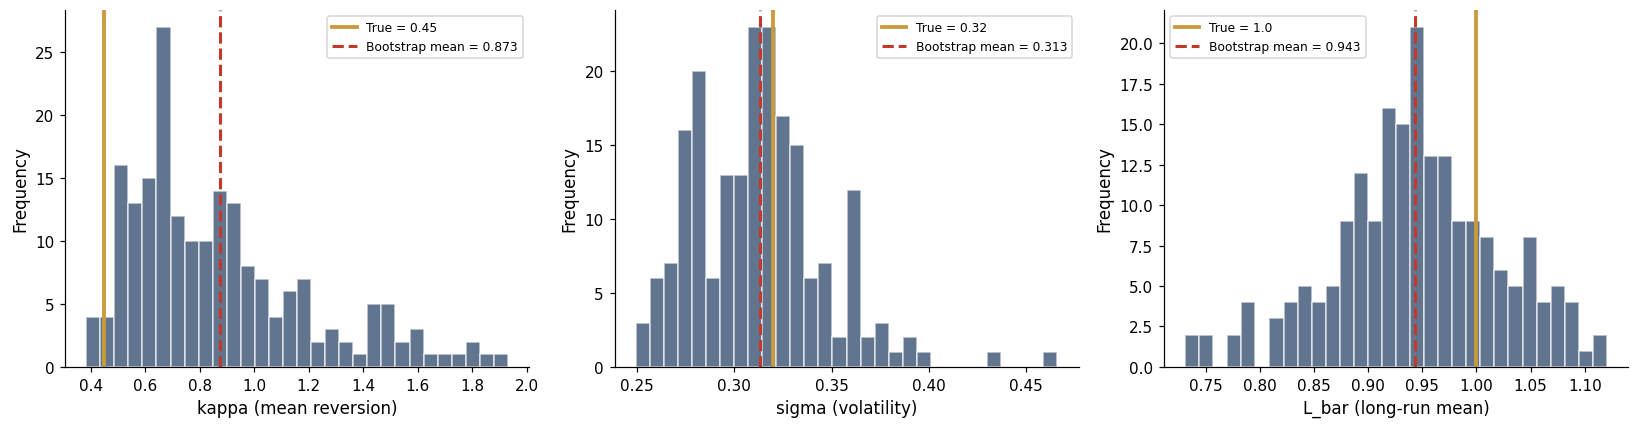

In [7]:
# Visualize bootstrap distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ["kappa (mean reversion)", "sigma (volatility)", "L_bar (long-run mean)"]
truths = [0.45, 0.32, 1.0]
for i, (ax, label, truth) in enumerate(zip(axes, labels, truths)):
    ax.hist(bootstrap_results[:, i], bins=30, color=NAVY, alpha=0.7, edgecolor="white")
    ax.axvline(truth, color=GOLD, linewidth=2.5, label=f"True = {truth}")
    ax.axvline(bootstrap_results[:, i].mean(), color=RED, linestyle="--", linewidth=2,
               label=f"Bootstrap mean = {bootstrap_results[:, i].mean():.3f}")
    ax.set(xlabel=label, ylabel="Frequency")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Robustness: what if the data isn't quite OU?

Real L_t may have jumps, regime shifts, or non-stationary parameters. Let's see what calibration produces if we add a jump component.

In [8]:
# Generate a jump-diffusion process: OU + occasional Poisson jumps
rng = np.random.default_rng(7)
n_steps = len(L_hist)
L_jd = np.empty(n_steps)
L_jd[0] = 1.0
jump_rate = 0.03  # 3% chance per quarter
jump_size_std = 0.4
for t in range(1, n_steps):
    eps = rng.standard_normal()
    jump = (rng.uniform() < jump_rate) * rng.normal(-0.8, jump_size_std)
    L_jd[t] = L_jd[t-1] + 0.45 * (1.0 - L_jd[t-1]) * 0.25 + 0.32 * 0.5 * eps + jump

# Calibrate as if it were pure OU
result_jd = calibrate_ou(L_jd, dt=0.25)
print("Jump-diffusion data, fit as OU:")
print(f"  kappa = {result_jd['kappa']:.3f}  (true OU part: 0.45)")
print(f"  sigma = {result_jd['sigma']:.3f}  (inflated by jump variance)")
print(f"  L_bar = {result_jd['L_bar']:.3f}")
print("\nNote: sigma is biased upward because the calibration absorbs jump variance.")

Jump-diffusion data, fit as OU:
  kappa = 0.410  (true OU part: 0.45)
  sigma = 0.401  (inflated by jump variance)
  L_bar = 0.712

Note: sigma is biased upward because the calibration absorbs jump variance.


## Suggested exercises

1. **Higher-frequency data.** Re-run calibration with `dt = 1/52` (weekly) data. How does the CI tighten?
2. **Misspecified data.** Generate a sample where `κ` changes from 0.45 to 0.25 at year 15 (a structural break). What does the constant-parameter calibration return?
3. **Autocorrelation check.** Compute the empirical autocorrelation of the L_t series at lags 1, 4, 8, 12, 20 quarters and compare to the OU prediction `exp(-κ·lag)`.
4. **Out-of-sample test.** Calibrate on the first 20 years; predict the distribution of L_t for the next 10 years; compare to actuals.
5. **(Track 2)** Implement a Kalman filter to estimate L_t when you only observe noisy proxies (e.g., secondary discount + measurement error). How does that change the calibration?

## Where this is used downstream

- Notebook 03 uses calibrated `(κ, σ, L̄)` to solve the HJB for `L*(t)`.
- Notebook 04 uses simulated L_t paths to compute LA-IRR and LA-PME.
- Notebook 05 uses calibrated parameters as inputs to the MFG fixed point.

## References

- Karatzas & Shreve, *Brownian Motion and Stochastic Calculus*, Ch. 5.
- Risken, *The Fokker-Planck Equation*, Ch. 4.
- Book Chapter 4 (OU process intuition); Chapter 19 (Itô calculus).
